# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import os, pathlib, subprocess, sys
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
TARGET = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
TARGET.parent.mkdir(parents=True, exist_ok=True)
if not TARGET.exists():
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
print(f'COURSE_ROOT={TARGET}')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 11</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Residuales, LayerNorm y MLP</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="../assets/audio/notebooks/11_residuales_layernorm_y_mlp_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Qué necesita un bloque Transformer además de atención para ser estable, expresivo y apilable?

En el notebook 10 estudiamos atención multi-cabeza: varias comparaciones paralelas que devuelven una representación con forma $(B,T,C)$. Esa pieza permite mezclar información entre posiciones, pero no basta para construir un bloque Transformer completo.

Este notebook introduce las piezas que permiten convertir la atención en un bloque entrenable: conexiones residuales para preservar señal, LayerNorm para estabilizar escalas internas y una MLP por posición para transformar canales sin mezclar posiciones.

## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar la función conceptual de las conexiones residuales, LayerNorm y la MLP dentro de un bloque Transformer.
2. Leer la formulación pre-norm y conectar cada término con una operación computacional.
3. Verificar que las ramas de atención y MLP conservan la forma $(B,T,C)$ para que puedan sumarse residualmente.
4. Interpretar estadísticas antes y después de LayerNorm sin confundir normalización con aprendizaje semántico.
5. Comparar qué ocurre al conservar o eliminar la suma residual en un experimento pequeño.

## Marco conceptual

La atención responde una pregunta: qué posiciones aportan información a cada posición. Sin embargo, un bloque Transformer necesita más que rutas de atención. También necesita preservar información, estabilizar activaciones y transformar representaciones por canal.

Las conexiones residuales suman la entrada de una rama con la salida de esa rama. Esto permite que el bloque aprenda cambios sobre una representación existente, en lugar de reemplazarla por completo. Por eso las ramas deben devolver la misma forma que reciben.

LayerNorm normaliza los canales de cada posición. No calcula estadísticas sobre todo el lote como BatchNorm; para cada posición, centra y reescala sus $C$ canales. En Transformers modernos suele usarse una variante pre-norm: se normaliza antes de atención y antes de la MLP.

La MLP, también llamada red feed-forward por posición, transforma canales de cada posición de manera independiente. No mezcla tokens ni posiciones; eso ya lo hizo la atención. Su papel es aumentar expresividad local: expandir canales, aplicar una no linealidad y volver a $C$ canales.

El límite conceptual es que estas piezas no producen lenguaje por sí solas. Son mecanismos de arquitectura que hacen posible entrenar y apilar bloques; su valor aparece al integrarse con atención, objetivo autoregresivo y optimización.

## Mapa visual del notebook

La figura resume la estructura pre-norm que usaremos como puente hacia el bloque decoder: cada rama recibe una versión normalizada, produce una corrección con forma $(B,T,C)$ y esa corrección se suma mediante una ruta residual.

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="../assets/figures/11_residuales_layernorm_y_mlp.png" alt="Residuales, LayerNorm y MLP" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La lectura correcta es estructural: atención mezcla posiciones, MLP transforma canales, LayerNorm estabiliza cada posición y las residuales mantienen una ruta directa de información. No debe leerse como una explicación completa del entrenamiento ni como evidencia de comprensión lingüística.

## Formulación matemática

Partimos de una representación:

$$
X \,\in\, \mathbb{R}^{B \times T \times C},
$$

donde $B$ es el tamaño del lote, $T$ la longitud de la secuencia y $C$ el número de canales por posición.

Esta ecuación se lee así: el bloque recibe un lote de secuencias; cada posición tiene un vector de $C$ canales.

Un bloque Transformer pre-norm se puede escribir como:

$$
U = X + \operatorname{Attn}(\operatorname{LN}(X)),
$$

$$
Y = U + \operatorname{MLP}(\operatorname{LN}(U)).
$$

Esta ecuación se lee así: antes de cada rama se normaliza la representación; la rama produce una corrección con la misma forma $(B,T,C)$; luego esa corrección se suma a la señal que venía por la ruta residual.

La compatibilidad de forma es obligatoria. Si $\operatorname{Attn}(\operatorname{LN}(X))$ o $\operatorname{MLP}(\operatorname{LN}(U))$ no regresaran a $(B,T,C)$, la suma residual no estaría definida y el bloque no podría apilarse de manera uniforme.

LayerNorm actúa sobre los canales de cada posición. Para un vector $x_{b,t,:}$:

$$
\operatorname{LN}(x_{b,t,:}) = \gamma \odot \frac{x_{b,t,:}-\mu_{b,t}}{\sqrt{\sigma^2_{b,t}+\epsilon}} + \beta.
$$

Esta ecuación se lee así: para cada ejemplo $b$ y posición $t$, se calcula media $\mu_{b,t}$ y varianza $\sigma^2_{b,t}$ sobre los $C$ canales. No se promedian ejemplos del batch ni posiciones de tiempo. Después se aplican parámetros aprendibles $\gamma$ y $\beta$, uno por canal.

La MLP por posición suele tener forma:

$$
\operatorname{MLP}(z)= W_2\,\phi(W_1z+b_1)+b_2,
$$

con una expansión intermedia, por ejemplo $C \rightarrow 4C \rightarrow C$. Aquí $z \in \mathbb{R}^{C}$ representa una posición individual. Esta ecuación se lee así: cada posición se transforma de manera independiente, expandiendo canales, aplicando una no linealidad y regresando a $C$ para poder sumar la residual.

En resumen: atención mezcla posiciones; la MLP transforma canales por posición; LayerNorm estabiliza escalas antes de cada rama; la residual preserva una ruta directa de información y de gradiente.

## Traducción tensorial

Estas piezas conservan la interfaz $(B,T,C)$, pero no hacen lo mismo.

| Componente | Entrada | Salida | Qué eje opera | Qué conserva |
|---|---:|---:|---|---|
| LayerNorm | $(B,T,C)$ | $(B,T,C)$ | calcula media/varianza sobre $C$ para cada $(b,t)$ | batch y posiciones |
| Atención | $(B,T,C)$ | $(B,T,C)$ | mezcla posiciones sobre $T$ | forma externa |
| MLP | $(B,T,C)$ | $(B,T,C)$ | transforma canales $C$ por posición | no mezcla posiciones |
| Residual | dos tensores $(B,T,C)$ | $(B,T,C)$ | suma señales compatibles | interfaz del bloque |

Esta tabla muestra por qué la conservación de forma no es un detalle menor: sin esa compatibilidad no se podrían sumar residuales ni apilar bloques de manera uniforme.

## Preparación del entorno

In [1]:
from pathlib import Path
import importlib
import sys
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings("ignore", message="Pandas requires version .*", category=UserWarning)
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.arquitectura_experimentos as arquitectura_experimentos
import fundamentos_transformers.componentes_interactivos as componentes_interactivos
import fundamentos_transformers.visualizacion as visualizacion

arquitectura_experimentos = importlib.reload(arquitectura_experimentos)
componentes_interactivos = importlib.reload(componentes_interactivos)
visualizacion = importlib.reload(visualizacion)

crear_explorador_residuales_layernorm_mlp = componentes_interactivos.crear_explorador_residuales_layernorm_mlp
configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento mínimo

Construiremos un tensor artificial $X$ con escala desplazada y aislaremos la rama

$$
\operatorname{LN} \rightarrow \operatorname{MLP} \rightarrow \text{residual}.
$$

No estamos implementando todavía el bloque completo; el objetivo es observar tres fenómenos locales:

1. LayerNorm normaliza canales por posición.
2. La MLP transforma cada posición sin cambiar la forma.
3. La residual conserva una ruta directa desde $X$ hasta la salida.

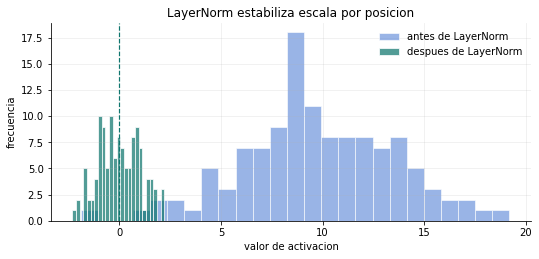

In [2]:
resultado_residuales = arquitectura_experimentos.preparar_residuales_layernorm_mlp(seed=7)

mostrar_tablas_en_columnas(
    [
        ("Auditoría eje por eje", resultado_residuales.operaciones),
        ("LayerNorm por posición", resultado_residuales.estadisticas),
        ("Con residual vs sin residual", resultado_residuales.comparacion),
        ("Parámetros", resultado_residuales.parametros),
    ],
    min_width="320px",
)


Las estadísticas muestran que LayerNorm no elimina la información posicional ni cambia la forma del tensor. Reescala los canales de cada posición para que las siguientes transformaciones operen sobre rangos más controlados.

La comparación con/sin residual no se debe leer como una competencia por tener una norma mayor o menor. Su función es mostrar que la residual preserva una ruta directa para la señal de entrada mientras la rama MLP aprende una corrección compatible.

## Visualización de escalas

La siguiente gráfica compara la distribución de valores antes y después de LayerNorm. No debe leerse como una prueba de aprendizaje, sino como evidencia de estabilización de escala por posición.

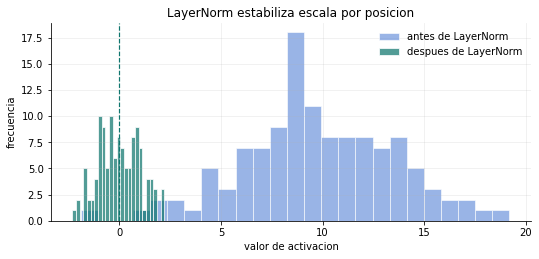

In [3]:
display(resultado_residuales.figura)
plt.close(resultado_residuales.figura)


## Explorador interactivo

El explorador permite variar el número de canales $C$, la escala de entrada y la presencia de residual. Úsalo para observar qué cambia en estadísticas, parámetros, forma tensorial y eje de operación de cada pieza.

In [4]:
crear_explorador_residuales_layernorm_mlp()

## Verificación de aprendizaje

Modifica el explorador y responde con evidencia:

1. Aumenta la escala de $X$. ¿Qué ocurre con la media y desviación antes de LayerNorm? ¿Qué ocurre después de LayerNorm?
2. Cambia $C$ de 4 a 16. ¿Cómo cambia el número de parámetros de LayerNorm y de la MLP?
3. Desactiva la residual. ¿Qué diferencia observas en la norma de la salida? ¿Por qué eso no significa que la opción sin residual sea mejor?
4. Identifica el eje sobre el que opera LayerNorm y explica por qué no es una normalización sobre batch.
5. Explica por qué la MLP puede transformar canales sin mezclar posiciones.
6. Justifica por qué todas las ramas deben regresar a forma $(B,T,C)$ para que exista la suma residual.

## Análisis crítico

El experimento muestra que LayerNorm estabiliza la escala por posición, la MLP introduce una transformación no lineal sobre canales y la residual conserva una ruta directa de información. Estas piezas permiten que el bloque no dependa de una única transformación destructiva.

La razón arquitectónica es la compatibilidad de forma. Atención y MLP pueden hacer operaciones distintas, pero ambas deben devolver $(B,T,C)$ para que la suma residual sea válida. Esta restricción también permite apilar bloques sin rediseñar la interfaz en cada capa.

La razón de entrenamiento es igual de importante: una residual no solo conserva valores hacia adelante; también ofrece una ruta directa para que la señal de gradiente atraviese muchas capas. Este notebook no mide entrenamiento profundo, pero prepara esa lectura estructural.

El límite del experimento es que no entrenamos un modelo ni evaluamos lenguaje. Solo observamos propiedades estructurales de las operaciones. Que LayerNorm estabilice escalas no implica que el modelo entienda la secuencia; implica que las activaciones quedan en un rango más manejable para el entrenamiento.

## Síntesis

La cadena operacional del notebook es:

$$
X \rightarrow \operatorname{LN}(X) \rightarrow \operatorname{Attn} \rightarrow U = X + \operatorname{Attn}(\operatorname{LN}(X)) \rightarrow \operatorname{LN}(U) \rightarrow \operatorname{MLP} \rightarrow Y = U + \operatorname{MLP}(\operatorname{LN}(U)).
$$

Esta cadena se lee así: se normaliza antes de cada rama, cada rama produce una corrección compatible en forma y la residual acumula esa corrección sobre la representación existente.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que el bloque Transformer no es solo atención: combina mezcla contextual, transformación local, normalización y rutas residuales para poder entrenarse y apilarse.
</div>

## Preguntas de discusión

1. ¿Por qué una conexión residual exige que entrada y salida tengan la misma forma?
2. ¿Sobre qué eje calcula estadísticas LayerNorm en un tensor $(B,T,C)$?
3. ¿Por qué la MLP transforma canales pero no mezcla posiciones?
4. ¿Qué riesgo interpretativo aparece si se afirma que LayerNorm “hace aprender mejor” sin analizar entrenamiento?
5. ¿Por qué estas piezas son necesarias antes de construir el bloque decoder completo?

## Continuidad

Ya tenemos las piezas principales: atención causal multi-cabeza, residuales, LayerNorm y MLP. El siguiente paso es integrarlas en una sola unidad computacional: el bloque Transformer decoder.

El notebook 12 construye ese bloque completo y verifica que pueda apilarse manteniendo la interfaz $(B,T,C)$.